# 🕸️ Exploring Functional Connectivity in *In Vitro* Neuronal Networks

In the previous notebook we looked at *when* neurons fire. Now we ask: **which neurons influence which other neurons?**

This is the field of **functional connectivity** — we use statistical methods to infer directed connections between neurons from their spike trains. The result is a **graph** (also called a *network*): a set of nodes (neurons) connected by edges (inferred connections).

We will use **modified Transfer Entropy (mTE)** as our connectivity measure. No maths required — we'll explain it as we go!

## ⚙️ Quick Setup

Same libraries as before, plus **NetworkX** — Python's standard library for creating, analysing, and visualising graphs.

In [7]:
# Install required libraries (only needed once).
# networkx is new here — it is Python's go-to library for graph analysis.
!pip install numpy matplotlib networkx

^C


In [8]:
import pickle          # for loading .pkl files
import numpy as np     # numerical computing
import matplotlib.pyplot as plt  # plotting
import networkx as nx  # graph creation and analysis

print('All libraries imported successfully!')

All libraries imported successfully!


In [9]:
# Global plot style settings — same as in the previous notebook.
# Run this once and all subsequent plots will automatically look clean.
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 1.2,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})
print('Plot style configured!')

Plot style configured!


## 📂 Load the Data

We load the same pickle file as before — it contains both the spike data and the precomputed mTE connectivity.

In [10]:
# ---- Update this path to match the location of the file on your laptop! ----
FILE_PATH = r'C:\Users\Giuli\Documents\Recover\BIORTC_Nigeria\2026\Data\In_Vitro\GBM_Progression_Data\PatientA_N0-4\ID1814_N0_DIV48_DATE20240618_1349_spontaneous_Patient1.raw_processed_info_metrics.pkl'

# Open and load the pickle file
with open(FILE_PATH, 'rb') as f:
    data = pickle.load(f)

# Extract the three entries from the dictionary
mte      = data['mTE']                 # the connectivity data — we'll explore this below
spikes   = data['SPIKES']              # spike trains (not used much here, but good to have)
duration = data['EXPERIMENT_DURATION'] # recording duration in milliseconds

print('Keys in the data dictionary:', list(data.keys()))
print(f'Recording duration  : {duration:.2f} ms')
print(f'Number of mTE edges : {len(mte)}')

Keys in the data dictionary: ['EXPERIMENT_DURATION', 'SPIKES', 'mTE']
Recording duration  : 86.76 ms
Number of mTE edges : 185


## 🔬 What is the mTE Data?

**Transfer Entropy (TE)** is an information-theoretic measure that asks:

> *Does knowing the recent past activity of neuron A help me predict the future activity of neuron B — beyond what B's own past already tells me?*

If yes, we say there is a **directed connection** from A → B, and the TE value quantifies how strong that influence is.

The `mTE` array stores only the **statistically significant** connections (i.e. those that passed a permutation test). Each row is one directed connection.

In [11]:
# Print the field names of the mTE structured array and show a few example rows.
# A structured array is like a table: each column has a name and a data type.

print('Fields in mTE:', mte.dtype.names)
print()
print('First 5 rows (each row = one directed connection):')
for row in mte[:5]:
    print(' ', row)

Fields in mTE: ('target', 'source', 'lag', 'te', 'te_pval', 'omnibus_te', 'omnibus_pval', 'te_source', 'target_entropy', 'norm_te', 'norm_omnibus_te')

First 5 rows (each row = one directed connection):
  (4.0, 22.0, 8.0, 0.00062838756, 0.005, 0.0020693012, 0.005, 0.00062838756, 0.03049541, 0.020605972, 0.06785615)
  (4.0, 30.0, 10.0, 0.000506055, 0.005, 0.0020693012, 0.005, 0.000506055, 0.03049541, 0.016594464, 0.06785615)
  (4.0, 50.0, 5.0, 0.00051594793, 0.005, 0.0020693012, 0.005, 0.00051594793, 0.03049541, 0.016918872, 0.06785615)
  (4.0, 5.0, 9.0, 0.00047292304, 0.005, 0.0020693012, 0.005, 0.00047292304, 0.03049541, 0.015508006, 0.06785615)
  (5.0, 55.0, 2.0, 0.01248204, 0.005, 0.014466152, 0.005, 0.01248204, 0.06544579, 0.19072334, 0.22104022)


In [12]:
# Let's summarise what each key field means:
#
#   source        : ID of the neuron sending the influence (the 'driver')
#   target        : ID of the neuron receiving the influence (the 'follower')
#   lag           : time delay in bins at which TE is maximal
#                   (how many time steps ahead does A predict B?)
#   te            : raw Transfer Entropy value (in bits)
#   norm_te       : TE normalised by the entropy of the target neuron
#                   → ranges from 0 to 1; easier to compare across neuron pairs
#                   → 0.1 means A explains 10% of B's uncertainty
#   te_pval       : p-value of the connection (only significant ones are stored,
#                   so all values here are small)
#   omnibus_te    : TE when all significant sources of a target are considered together
#   target_entropy: entropy of the target neuron (its baseline uncertainty)

print(f'Unique source neurons : {len(np.unique(mte["source"]))}')
print(f'Unique target neurons : {len(np.unique(mte["target"]))}')
print(f'Lag range             : {int(mte["lag"].min())} – {int(mte["lag"].max())} bins')
print(f'norm_te range         : {mte["norm_te"].min():.3f} – {mte["norm_te"].max():.3f}')
print()
print('Note: not all neurons appear as sources — only those that significantly')
print('predict at least one other neuron are included as source nodes.')

Unique source neurons : 40
Unique target neurons : 57
Lag range             : 1 – 10 bins
norm_te range         : 0.004 – 0.414

Note: not all neurons appear as sources — only those that significantly
predict at least one other neuron are included as source nodes.


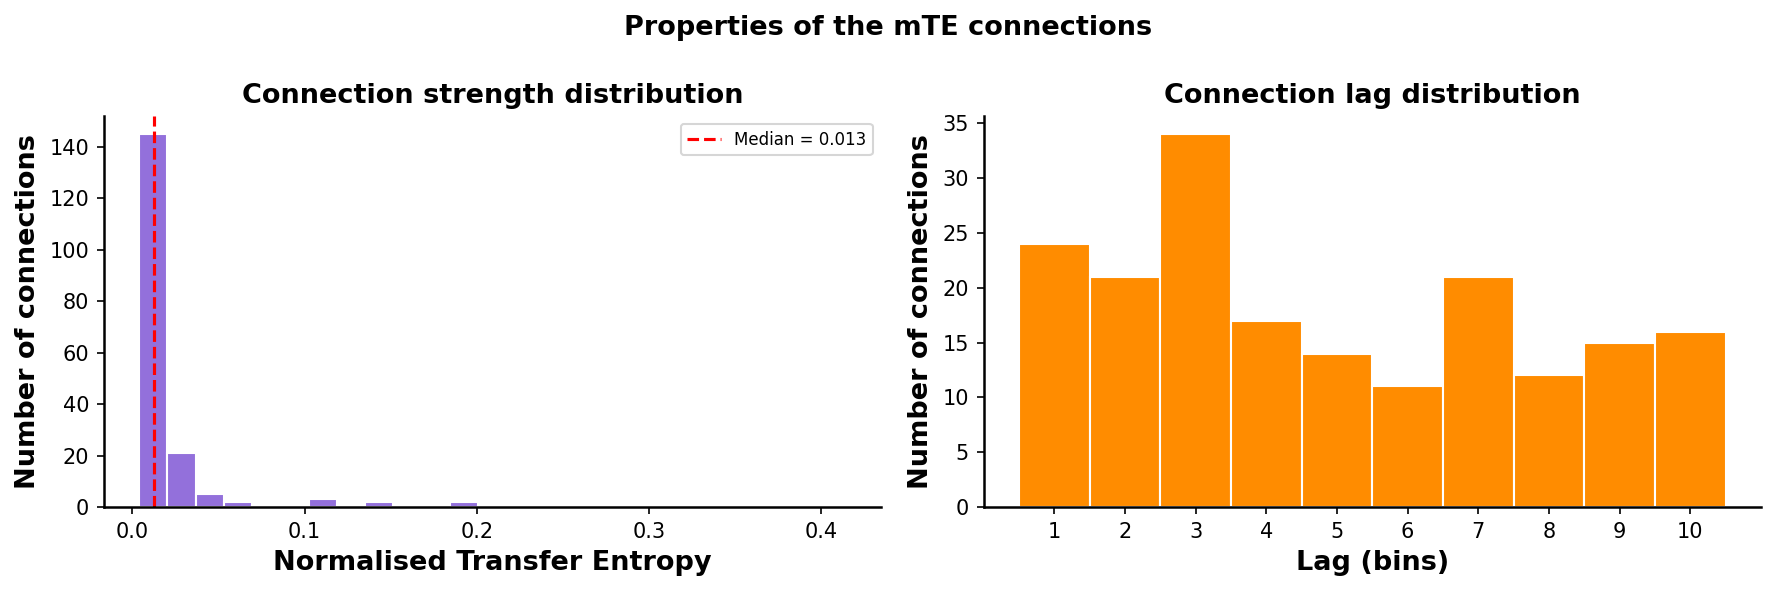

In [13]:
# --- Distribution of connection strengths (norm_te) and lags ---
#
# Before building the graph it is always worth looking at the raw values:
#   - Are most connections weak or strong?
#   - At what lag do connections peak? (short lag = fast influence)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: distribution of normalised TE (connection strength) ---
axes[0].hist(mte['norm_te'], bins=25, color='mediumpurple', edgecolor='white')
axes[0].set_xlabel('Normalised Transfer Entropy')
axes[0].set_ylabel('Number of connections')
axes[0].set_title('Connection strength distribution')
# axvline draws a vertical reference line at the median
axes[0].axvline(np.median(mte['norm_te']), color='red', linestyle='--',
                label=f'Median = {np.median(mte["norm_te"]):.3f}')
axes[0].legend()

# --- Plot 2: distribution of lags ---
# range(1, max+2) ensures each integer lag gets its own bar
lag_bins = range(int(mte['lag'].min()), int(mte['lag'].max()) + 2)
axes[1].hist(mte['lag'], bins=lag_bins, color='darkorange', edgecolor='white', align='left')
axes[1].set_xlabel('Lag (bins)')
axes[1].set_ylabel('Number of connections')
axes[1].set_title('Connection lag distribution')
axes[1].set_xticks(list(lag_bins)[:-1])  # one tick per integer lag value

plt.suptitle('Properties of the mTE connections', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 👉 Questions:
#    - Are most connections weak (norm_te close to 0) or are there some strong ones?
#    - Is there a preferred lag? What might that tell us about the speed of neural communication?

### 💬 What does the lag mean?

The **lag** is the time offset (in bins) at which the Transfer Entropy is maximised. If a connection has lag = 3 and each bin is 1 ms, it means that neuron A's activity 3 ms in the past best predicts neuron B's current activity.

> 🧠 *In the brain, monosynaptic connections typically have delays of a few ms. Where could longer lags come from?*

## 🕸️ Build and Plot the Graph

Now we turn the mTE table into a proper **directed weighted graph** using NetworkX.

- Each **node** = one neuron
- Each **edge** = a significant directed connection (source → target)
- Each edge has a **weight** = norm_te (connection strength) and a **lag** attribute

In [14]:
# --- Build the directed weighted graph ---
#
# nx.DiGraph() creates an empty *directed* graph.
# 'Directed' means edges have a direction: A → B is different from B → A.
# This is important here because TE is asymmetric — A may predict B
# without B predicting A.

G = nx.DiGraph()  # DiGraph = Directed Graph

# Loop over every row in the mTE array and add one edge per connection
for row in mte:
    G.add_edge(
        int(row['source']),         # the sending neuron (integer ID)
        int(row['target']),         # the receiving neuron (integer ID)
        weight=float(row['norm_te']),  # edge weight = connection strength
        lag=float(row['lag'])          # stored as an extra edge attribute
    )
    # Note: if we add an edge between two nodes that don't yet exist,
    # NetworkX automatically creates those nodes. Very convenient!

# Basic graph summary
print(f'Number of nodes (neurons)    : {G.number_of_nodes()}')
print(f'Number of edges (connections): {G.number_of_edges()}')
print(f'Graph density                : {nx.density(G):.4f}')
# Density = actual edges / maximum possible edges
# 0 = no connections, 1 = every neuron connected to every other
print(f'Weakly connected             : {nx.is_weakly_connected(G)}')
# 'Weakly connected' means you can reach any node from any other
# if you ignore edge directions — i.e. the graph is one piece, not isolated islands

Number of nodes (neurons)    : 57
Number of edges (connections): 185
Graph density                : 0.0580
Weakly connected             : True


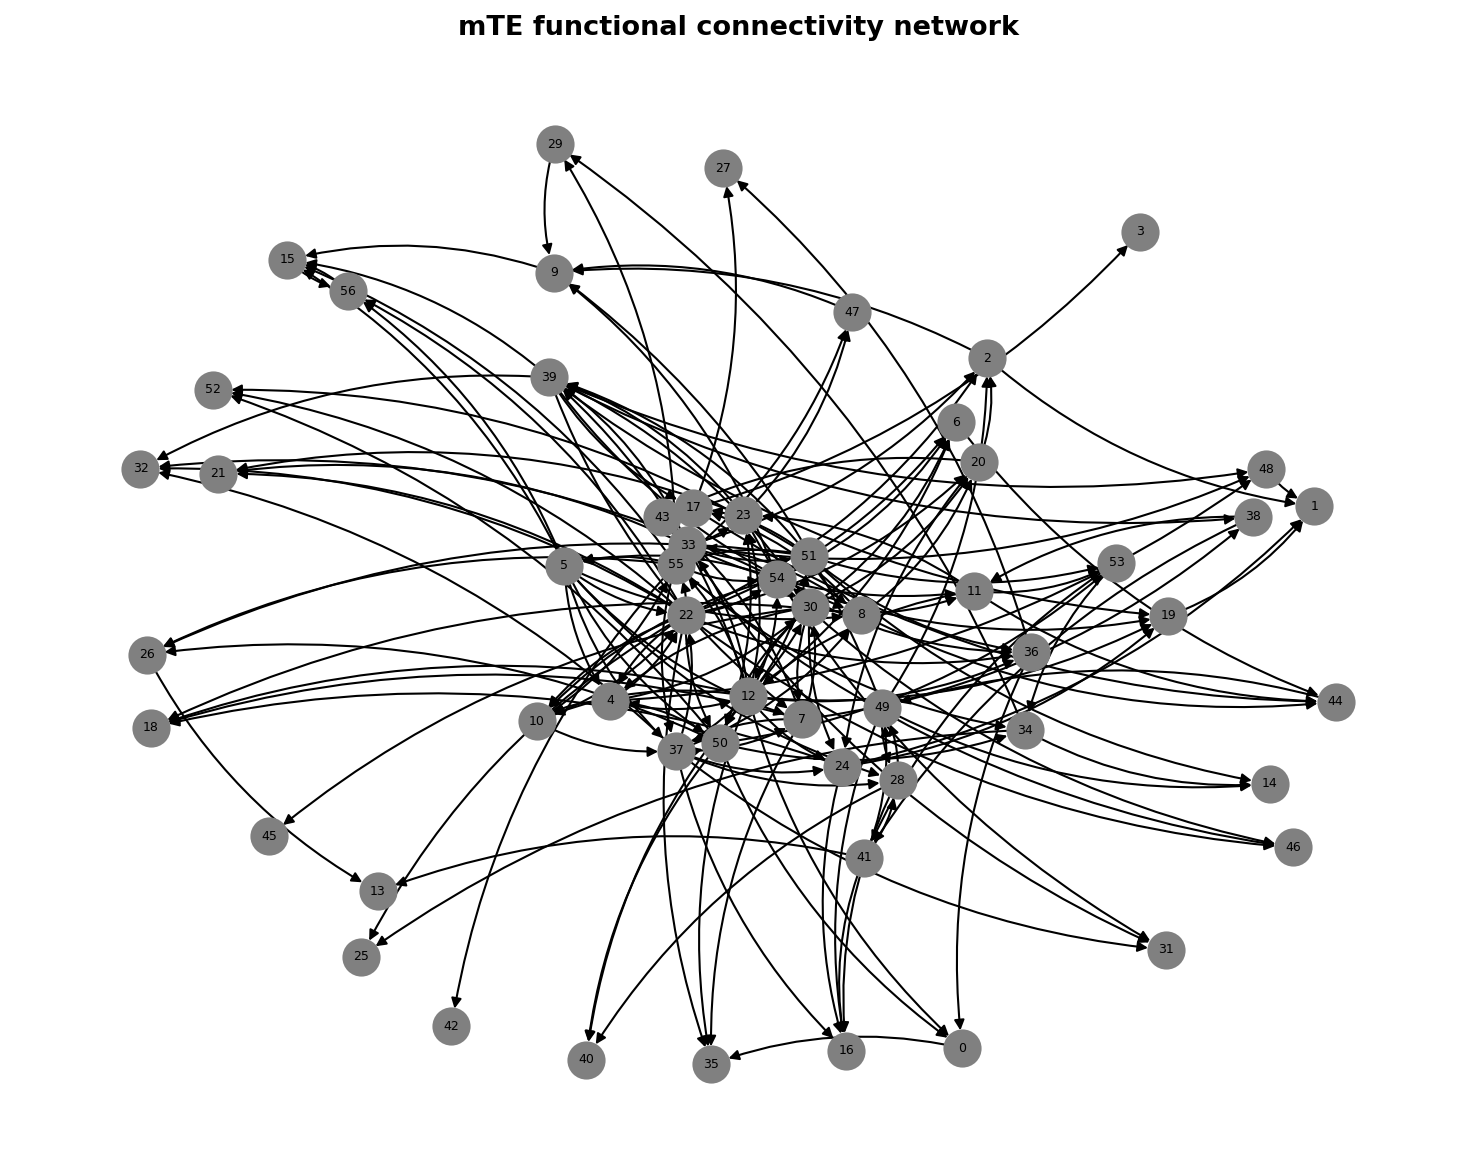

In [19]:
# --- Plot the graph ---
# nx.draw() handles everything automatically with sensible defaults.
# spectral_layout positions nodes based on the graph structure,
# placing strongly connected neurons closer together.

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw(G, pos, ax=ax, with_labels=True, font_size=6,
        node_color='grey', edge_color='black',
        connectionstyle='arc3,rad=0.15')

ax.set_title('mTE functional connectivity network')
plt.tight_layout()
plt.show()

# 👉 Questions:
#    - Do you see clusters of nodes with many connections between them?
#    - Are there any nodes with no outgoing edges?

Mean in-degree  : 3.25
Mean out-degree : 3.25
Max out-degree  : 16  (the biggest hub)


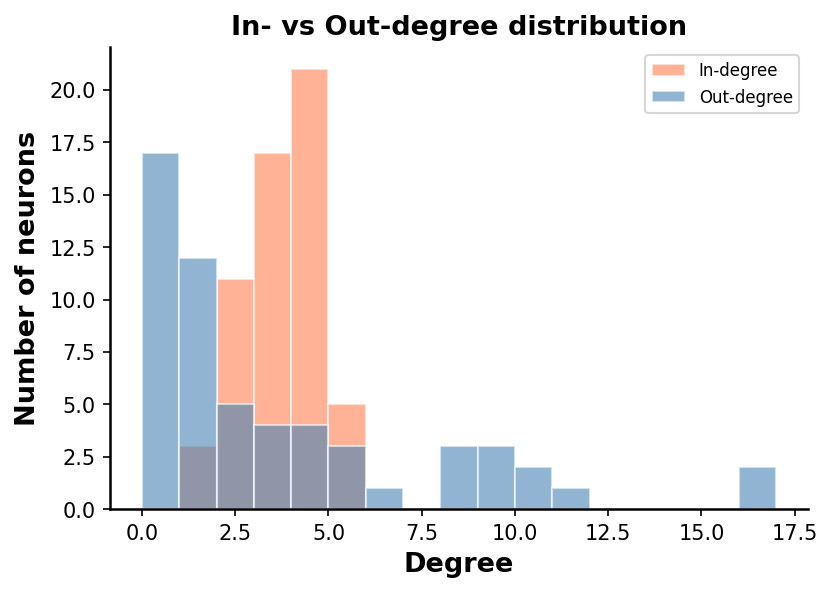

In [22]:
# --- Degree distribution ---
#
# The 'degree' of a node is the number of edges connected to it.
# Because our graph is DIRECTED, we distinguish:
#   In-degree  = number of incoming edges = how many neurons influence this one
#   Out-degree = number of outgoing edges = how many neurons this one influences
#
# The degree distribution tells us about the network's connectivity structure:
#   - A random graph has a bell-shaped (Poisson) degree distribution
#   - A 'scale-free' network has a heavy-tailed (power-law) distribution,
#     meaning a few 'hub' nodes have very high degree

in_deg_vals  = [G.in_degree(n)  for n in G.nodes()]
out_deg_vals = [G.out_degree(n) for n in G.nodes()]

# Use integer bins so each degree value gets its own bar
max_deg = max(max(in_deg_vals), max(out_deg_vals))
bins = range(0, max_deg + 2)  # +2 so the last bar is included

fig, axes = plt.subplots(1, 1, figsize=(6, 4))

# --- Histogram of in- and out-degree on the same axes ---
axes.hist(in_deg_vals,  bins=bins, alpha=0.6, label='In-degree',
             color='coral',     edgecolor='white')
axes.hist(out_deg_vals, bins=bins, alpha=0.6, label='Out-degree',
             color='steelblue', edgecolor='white')
axes.set_xlabel('Degree')
axes.set_ylabel('Number of neurons')
axes.set_title('In- vs Out-degree distribution')
axes.legend()

print(f'Mean in-degree  : {np.mean(in_deg_vals):.2f}')
print(f'Mean out-degree : {np.mean(out_deg_vals):.2f}')
print(f'Max out-degree  : {max(out_deg_vals)}  (the biggest hub)')

## 📐 Graph Metrics

NetworkX has a rich library of graph analysis functions. Try to look into the one mostly used in neuroscience: 

### Key metrics at a glance

| Metric | What it measures |
|---|---|
| **Density** | Fraction of possible edges that actually exist |
| **Clustering coefficient** | How often a node's neighbours are also connected to each other (local cliquishness) |
| **Average path length** | On average, how many edges does it take to get from one node to any other? |
| **Small-world index (σ)** | Is clustering high AND path length short? σ > 1 suggests small-world topology |
| **Betweenness centrality** | How often does a node lie on the shortest path between other nodes? (bridge/hub measure) |
| **PageRank** | How much influence does a node have, weighted by how influential its predecessors are? |

> 📖 *Feel free to explore the [NetworkX documentation](https://networkx.org/documentation/stable/reference/algorithms/index.html) for many more!*